In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [3]:
from pathlib import Path

from scipy.special import jv, yv

from rebinding.fig_utils import create_color_gradient, defaultStyle, save_fig
from rebinding.micropk import load_sol_to_model

defaultStyle(fs=14)
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

# Washout curves with various MT

In [4]:
def major_eigv_cylindrical_diffusion(r1, r2):
    r1 = config.rcap
    r2 = config.tissue_length
    lamda = np.linspace(1e-4, 0.005, 100)
    f1 = jv(0, lamda**0.5 * r1) * yv(1, lamda**0.5 * r2)
    f2 = jv(1, lamda**0.5 * r2) * yv(0, lamda**0.5 * r1)
    eigv = lamda[np.argmin(abs(f1 - f2))]
    return eigv

Saving figure fig1_washout_MT


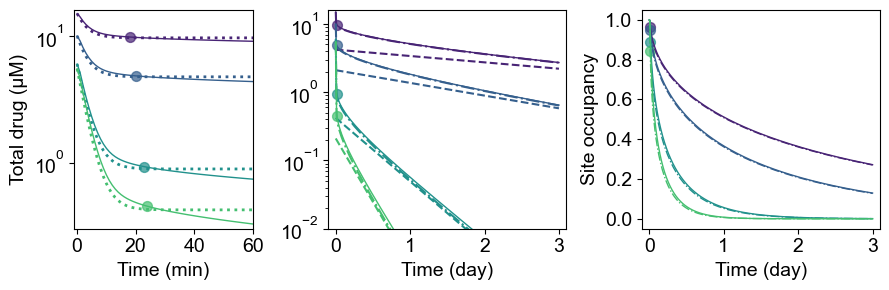

In [5]:
# List of pairs to load and plot
pairs = [
    (1, 2),
    (14, 17),
    (13, 16),
    (12, 15),
]

cmap = mpl.colormaps["viridis"]
colors = [cmap(x) for x in np.linspace(0.1, 0.7, len(pairs))]

# Create the figure once
fig = plt.figure(figsize=(9, 3))
gs = GridSpec(1, 3, width_ratios=[1.5, 2, 2])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
plt.subplots_adjust(wspace=0.1)

# Loop through each pair
for i, (file_no_num, file_no_approx) in enumerate(pairs):
    # Current color for this pair
    current_color = colors[i % len(colors)]

    # Load models
    micropk = load_sol_to_model(Path(f"../num_expt/cpBL{str(file_no_num).zfill(3)}/"))
    micropk_approx = load_sol_to_model(
        Path(f"../num_expt/cpBL{str(file_no_approx).zfill(3)}/")
    )

    # Calculate values
    loc = -1
    c_approx = micropk_approx.sol[0][:, -1]
    config = micropk.tissue_config
    r = config.kd / config.mt
    u0 = c_approx / config.mt
    uc = config.mt * (1 - np.sqrt(r))
    vc = 0.5 * (
        uc
        + config.mt
        + config.kd
        - np.sqrt((uc + config.mt + config.kd) ** 2 - 4 * config.mt * uc)
    )
    eigv = major_eigv_cylindrical_diffusion(config.rcap, config.tissue_length)

    # Two asymptotes
    # u_thresh = 1 - r ** 0.5
    # vc = 0.5 * (u_thresh + 1 + r - np.sqrt((u_thresh + 1 + r) ** 2 - 4 * u_thresh)),
    u0_approx_1 = vc + (c_approx[0] - vc) * np.exp(-eigv * config.D * micropk.t)
    u0_approx_2 = 0.42 * config.mt * np.exp(-r * micropk.t * eigv * config.D)

    # Plot with pair-specific labels
    pair_label = f"Pair {i+1}: ({file_no_num},{file_no_approx})"

    # Curves for ax1
    num_curve = ax1.plot(
        micropk.t,
        micropk.sol[0][:, loc],
        c=current_color,
        lw=1,
    )
    ax2.plot(
        micropk.t,
        micropk.sol[0][:, loc],
        c=current_color,
        lw=1,
    )

    rebinding_curve = ax2.plot(micropk.t, u0_approx_2, ls="--", c=current_color)
    approx_curve = ax2.plot(
        micropk_approx.t,
        micropk_approx.sol[0][:, loc],
        ls="-.",
        c=current_color,
        lw=1.5,
    )

    free_diffusion_curve = ax1.plot(micropk.t, u0_approx_1, lw=2, c=current_color, ls=":")

    # Curves for ax3
    ax3.plot(
        micropk.t,
        micropk.sol[1][:, loc] / config.mt,
        c=current_color,
        lw=1,
        label=f"{config.mt}",
    )

    ax3.plot(
        micropk_approx.t,
        0.5 * (u0 + 1 + r - np.sqrt((u0 + 1 + r) ** 2 - 4 * u0)),
        ls="-.",
        c=current_color,
        lw=1,
    )

    # Scatter points
    sol_approx = micropk_approx.sol[0][:, loc]
    time_transit = micropk.t[np.argmin(abs(micropk.sol[0][:, loc] - uc))]
    for cx in [ax1, ax2]:
        transition_point = cx.scatter(
            [time_transit],
            uc,
            s=50,
            color=current_color,
            alpha=0.7,
        )

    sol_approx_2 = micropk_approx.sol[1][:, loc]
    time_transit_2 = micropk_approx.t[np.argmin(abs(sol_approx_2 - vc))]
    ax3.scatter(
        [time_transit_2], [vc / config.mt], s=50, color=current_color, alpha=0.7
    )
    
    if i == 0:
        legend_hdls_1 = [
            num_curve[0],
            free_diffusion_curve[0],
            transition_point,
        ]
        legend_hdls_2 = [
            num_curve[0],
            approx_curve[0],
            rebinding_curve[0],
            transition_point,
        ]

# Set common formatting for both axes
ax1.set_yscale("log")
ax2.set_yscale("log")
ax1.set_ylim([0.3, 16])
ax2.set_ylim([0.01, 16])
# ax1.set_yticks(range(1, 16, 2))
ax1.set_ylabel("Total drug (μM)")
# ax1.set_yticklabels([str(i) for i in range(3, 16, 2)])
ax1.tick_params(axis="y", which="minor", left=False, labelleft=False)
ax3.set_ylabel("Site occupancy")
ax3.set_yticks([0.2 * n for n in range(0, 6)])
# ax1.legend(
#     legend_hdls_1,
#     ["Numerical", "Stage I: Free diffusion", "Transition point"],
#     fontsize=10,
#     bbox_to_anchor=(1, .5),
# )
# ax2.legend(
#     legend_hdls_2,
#     ["Numerical", "Approx.", "Stage II: Rebinding", "Transition point"],
#     fontsize=12,
#     ncols=2,
#     bbox_to_anchor=(1.1, 1.25),
# )
# ax3.legend(title="Tubulin (μM)", fontsize=12, title_fontsize=12, bbox_to_anchor=(0.8, 1.3), ncols=2)

# Set x-axis formatting
for bx in [ax2, ax3]:
    xticks = np.arange(0, micropk.solver_config.tmax + 1, 3600 * 24)
    bx.set_xticks(xticks)
    bx.set_xticklabels(xticks // 3600 // 24)
    bx.set_xlabel("Time (day)")
    bx.set_xlim(np.array([-0.1, 3.1]) * 3600 * 24)
    
xticks = np.arange(0, 3610, 1200)
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks // 60)
ax1.set_xlabel("Time (min)")
ax1.set_xlim([-60, 3600 * 1])

# Save the figure
save_fig("fig1_washout_MT", fmt="png", dpi=300)

# Legends

Saving figure fig1_washout_MT_leg


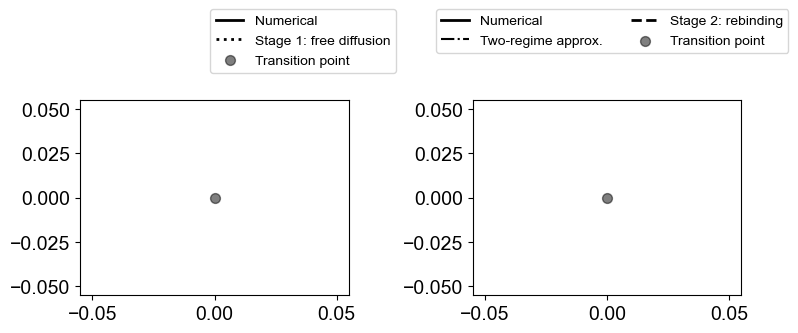

In [6]:
_, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].plot([0], [0], lw=2, label="Numerical", color="k")
ax[0].plot([0], [0], lw=2, label="Stage 1: free diffusion", color="k", ls=":")
ax[0].scatter([0], [0], s=50, alpha=0.5, label="Transition point", color="k")
ax[0].legend()
ax[1].plot([0], [0], lw=2, label="Numerical", color="k")
ax[1].plot([0], [0], label="Two-regime approx.", color="k", ls="-.")
ax[1].plot([0], [0], lw=2, label="Stage 2: rebinding", color="k", ls="--")
ax[1].scatter([0], [0], s=50, alpha=0.5, label="Transition point", color="k")
ax[0].legend(bbox_to_anchor=(1, 1, 0.2, 0.5))
ax[1].legend(ncols=2, bbox_to_anchor=(1, 1, 0.2, 0.5))
save_fig("fig1_washout_MT_leg", fmt="png", dpi=300)

# Washout curve of various fu

Saving figure fig1_washout_fu


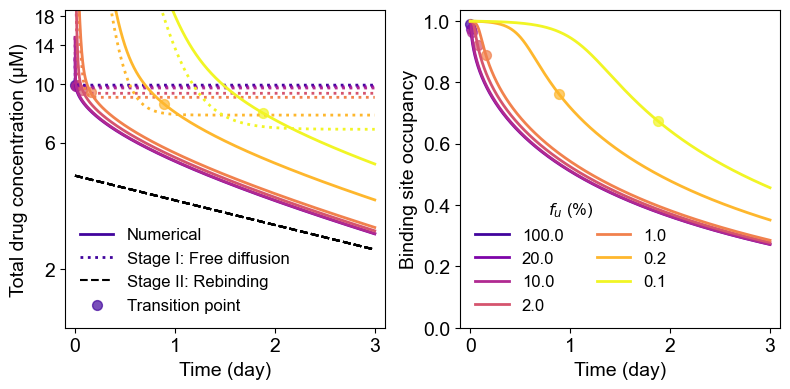

In [7]:
# List of pairs to load and plot
pairs = (
    [(i, i + 8) for i in range(18, 20)] + [(1, 2)] + [(i, i + 8) for i in range(20, 24)]
)

# Different colors for each pair
cmap = mpl.colormaps["plasma"]
colors = [cmap(x) for x in np.linspace(0.1, 0.99, len(pairs))]

# Create the figure once
_, ax = plt.subplots(1, 2, figsize=(8, 4))
plt.subplots_adjust(wspace=0.3)
ax1, ax2 = ax.flatten()

# Loop through each pair
for i, (file_no_num, file_no_approx) in enumerate(pairs):
    # Current color for this pair
    current_color = colors[i % len(colors)]

    # Load models
    micropk = load_sol_to_model(Path(f"../num_expt/cpBL{str(file_no_num).zfill(3)}/"))
    micropk_approx = load_sol_to_model(
        Path(f"../num_expt/cpBL{str(file_no_approx).zfill(3)}/")
    )
    # micropk.sol[0] = micropk.t[micropk.t < 3600 * 24]
    # micropk.t = micropk.t[micropk.t < 3600 * 24]

    # Calculate values
    loc = -1
    c_approx = micropk_approx.sol[0][:, -1]
    config = micropk.tissue_config
    r = config.kd / config.mt
    u0 = c_approx / config.mt
    uc = config.mt * (1 - np.sqrt(r))
    vc = 0.5 * (
        uc
        + config.mt
        + config.kd
        - np.sqrt((uc + config.mt + config.kd) ** 2 - 4 * config.mt * uc)
    )
    eigv = major_eigv_cylindrical_diffusion(config.rcap, config.tissue_length)

    # Two asymptotes
    u0_approx_1 = vc + (c_approx[0] - vc) * np.exp(-eigv * config.D * micropk.t)
    u0_approx_2 = 0.45 * config.mt * np.exp(-r * micropk.t * eigv * config.D)

    # Plot with pair-specific labels
    pair_label = f"Pair {i+1}: ({file_no_num},{file_no_approx})"

    # Curves for ax1
    num_curve = ax1.plot(
        micropk.t,
        micropk.sol[0][:, loc],
        c=current_color,
        lw=2,
    )

    # Plot asymptotes
    rebinding_curve = ax1.plot(micropk.t, u0_approx_2, ls="--", c="k")

    # approx_curve = ax1.plot(
    #     micropk_approx.t,
    #     micropk_approx.sol[0][:, loc],
    #     ls="-.",
    #     c=current_color,
    #     lw=1.5,
    # )

    free_diffusion_curve = ax1.plot(
        micropk.t, u0_approx_1, lw=2, c=current_color, linestyle=":"
    )

    # Curves for ax2
    ax2.plot(
        micropk.t,
        micropk.sol[1][:, loc] / config.mt,
        c=current_color,
        lw=2,
        label=f"{0.0005 / config.kd * 100}",
    )

    # if i > 0:
    #     ax2.plot(
    #         micropk_approx.t,
    #         0.5 * (u0 + 1 + r - np.sqrt((u0 + 1 + r) ** 2 - 4 * u0)),
    #         ls="-.",
    #         c=current_color,
    #         lw=1.5,
    #     )

    # Scatter points
    c_thresh = (1 - np.sqrt(r)) * config.mt
    sol = micropk.sol[0][:, loc]
    time_transit = micropk_approx.t[np.argmin(abs(sol - c_thresh))]
    transit_point = ax1.scatter(
        [time_transit],
        (1 - np.sqrt(r)) * config.mt,
        s=50,
        color=current_color,
        alpha=0.7,
    )
    
    if i == 0:
        legend_hdls = [
            num_curve[0],
            free_diffusion_curve[0],
            rebinding_curve[0],
            transit_point,
        ]


    sol_2 = micropk.sol[1][:, loc]
    time_transit_2 = micropk_approx.t[np.argmin(abs(sol_2 - vc))]
    ax2.scatter(
        [time_transit_2], [vc / config.mt], s=50, color=current_color, alpha=0.7
    )

# Set common formatting for both axes
ax1.set_yscale("log")
ax1.set_ylim([1.2, 19])
ax1.set_yticks(range(2, 20, 4))
ax1.set_ylabel("Total drug concentration (μM)")
ax1.set_yticklabels([str(i) for i in range(2, 20, 4)])
ax1.tick_params(axis="y", which="minor", left=False, labelleft=False)
ax2.set_ylabel("Binding site occupancy")
ax2.set_yticks([0.2 * n for n in range(0, 6)])
ax1.legend(legend_hdls, ["Numerical", "Stage I: Free diffusion", "Stage II: Rebinding", "Transition point"], fontsize=12, frameon=False) # , bbox_to_anchor=(0.21, 1.05))
ax2.legend(title="$f_u$ (%)", fontsize=12, title_fontsize=12, ncols=2, loc="lower left", frameon=False)

# Set x-axis formatting
for bx in [ax1, ax2]:
    xticks = np.arange(0, micropk.solver_config.tmax + 1, 3600 * 24)
    bx.set_xticks(xticks)
    bx.set_xticklabels(xticks // 3600 // 24)
    bx.set_xlabel("Time (day)")
    bx.set_xlim(np.array([-0.1, 3.1]) * 3600 * 24)

# Save the figure
save_fig("fig1_washout_fu", fmt="png", dpi=300)

# Kymograph

Saving figure FigEx1_1d_kymograph


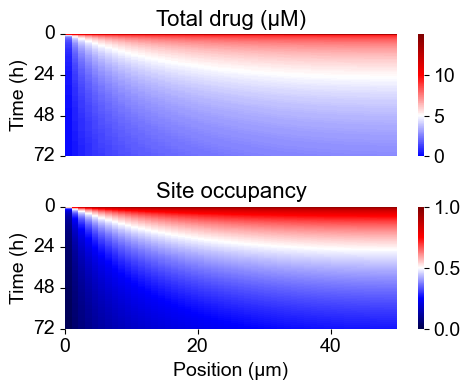

In [8]:
file_no_num = 1
micropk = load_sol_to_model(Path(f"../num_expt/cpBL{str(file_no_num).zfill(3)}/"))
fig, ax = plt.subplots(2, 1, figsize=(5, 4))
plt.subplots_adjust(wspace=0.03, hspace=0.02)
micropk.plot_kymograph(
    ax=ax, tspan=72 * 3600 // micropk.solver_config.dt_track, ylabel="Time (d)"
)
# micropk_approx.plot_kymograph(ax=ax[1], tspan=72 * 3600 // micropk.solver_config.dt_track, ylabel="Time (d)")
ax[0].set_title("Total drug (μM)", fontsize=16)
ax[1].set_title("Site occupancy", fontsize=16)
ax[0].set_xlabel("")
ax[0].set_xticks([])
fig.axes[2].set_label("PTX (μM)")
ax[1].set_xlabel("Position (μm)")
ax[1].set_xticks(range(0, 50, 20))
for bx in ax:
    bx.set_ylabel("Time (h)")
save_fig("FigEx1_1d_kymograph", fmt="png", dpi=300)

Saving figure FigEx1_1d_kymograph_approx


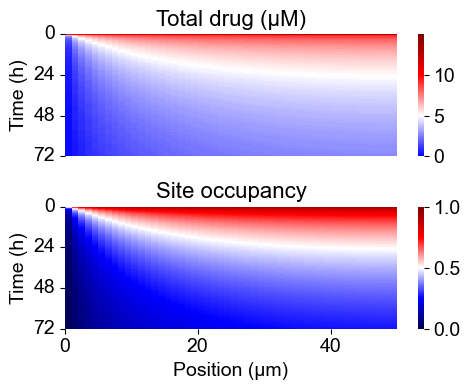

In [9]:
file_no_num = 2
micropk = load_sol_to_model(Path(f"../num_expt/cpBL{str(file_no_num).zfill(3)}/"))
fig, ax = plt.subplots(2, 1, figsize=(5, 4))
plt.subplots_adjust(wspace=0.03, hspace=0.02)
micropk.plot_kymograph(
    ax=ax, tspan=72 * 3600 // micropk.solver_config.dt_track, ylabel="Time (d)"
)
# micropk_approx.plot_kymograph(ax=ax[1], tspan=72 * 3600 // micropk.solver_config.dt_track, ylabel="Time (d)")
ax[0].set_title("Total drug (μM)", fontsize=16)
ax[1].set_title("Site occupancy", fontsize=16)
ax[0].set_xlabel("")
ax[0].set_xticks([])
fig.axes[2].set_label("PTX (μM)")
ax[1].set_xlabel("Position (μm)")
ax[1].set_xticks(range(0, 50, 20))
for bx in ax:
    bx.set_ylabel("Time (h)")
save_fig("FigEx1_1d_kymograph_approx", fmt="png", dpi=300)